In [1]:
# 🔹 CELDA 1: Introducción a RNN

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("SEMANA 9: RECURRENT NEURAL NETWORKS (RNN/LSTM)")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Explica qué son RNNs, por qué existen, 
y por qué CNN no sirve para secuencias.

CONCEPTOS CLAVE:
- CNN: Procesa espacios (imágenes)
- RNN: Procesa SECUENCIAS (time series, texto)
- Diferencia: RNN tiene MEMORIA
""")

print("""
SECUENCIAS vs IMÁGENES:

Imagen (CNN):              Secuencia (RNN):
[Píxel 1][Píxel 2]...    [Paso 1]→[Paso 2]→[Paso 3]...
Todo a la vez             Uno por uno (pero recuerda anterior)

EJEMPLO:
CNN: Mirar foto, clasificar "es un gato"
RNN: Leer frase palabra-por-palabra, predecir siguiente palabra

ARQUITECTURA RNN:
Input → [RNN Cell con memoria] → Output
         ↑                          ↓
         └──────────────────────────┘
              (feedback: memoria del pasado)

PROBLEMA: RNN básica tiene "vanishing gradient"
SOLUCIÓN: LSTM (Long Short-Term Memory)
""")


SEMANA 9: RECURRENT NEURAL NETWORKS (RNN/LSTM)

¿QUÉ HACE ESTA CELDA?
Explica qué son RNNs, por qué existen, 
y por qué CNN no sirve para secuencias.

CONCEPTOS CLAVE:
- CNN: Procesa espacios (imágenes)
- RNN: Procesa SECUENCIAS (time series, texto)
- Diferencia: RNN tiene MEMORIA


SECUENCIAS vs IMÁGENES:

Imagen (CNN):              Secuencia (RNN):
[Píxel 1][Píxel 2]...    [Paso 1]→[Paso 2]→[Paso 3]...
Todo a la vez             Uno por uno (pero recuerda anterior)

EJEMPLO:
CNN: Mirar foto, clasificar "es un gato"
RNN: Leer frase palabra-por-palabra, predecir siguiente palabra

ARQUITECTURA RNN:
Input → [RNN Cell con memoria] → Output
         ↑                          ↓
         └──────────────────────────┘
              (feedback: memoria del pasado)

PROBLEMA: RNN básica tiene "vanishing gradient"
SOLUCIÓN: LSTM (Long Short-Term Memory)



In [2]:
# 🔹 CELDA 2: RNN Manual (Intuición)

print("\n" + "=" * 60)
print("RNN MANUAL (INTUICIÓN)")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Implementa RNN manualmente para que ENTIENDAS 
cómo funciona la "memoria" en secuencias.

ESTO NO LO USAREMOS EN PROD (es lento),
solo para ENTENDER.
""")

# Ejemplo: Predicción de siguiente número en secuencia
sequence = [1, 2, 3, 4, 5, 6, 7, 8, 9]  # Secuencia simple

print(f"\nSecuencia: {sequence}")
print("Tarea: Predecir el siguiente número\n")

class SimpleRNN:
    def __init__(self, hidden_size=10):
        self.h = np.zeros(hidden_size)  # Estado oculto (MEMORIA)
        self.hidden_size = hidden_size
        
        # Pesos (random inicialmente)
        self.Wxh = np.random.randn(hidden_size, 1) * 0.01  # Input → Hidden
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01  # Hidden → Hidden
        self.Why = np.random.randn(1, hidden_size) * 0.01  # Hidden → Output
    
    def forward(self, x):
        """
        ¿QUÉ HACE?
        Procesa UN paso de la secuencia.
        
        FÓRMULA:
        h_new = tanh(Wxh @ x + Whh @ h_old)
        y = Why @ h_new
        
        h_new: NUEVA MEMORIA (recuerda x + pasado)
        y: PREDICCIÓN
        """
        self.h = np.tanh(self.Wxh @ x + self.Whh @ self.h)
        y = self.Why @ self.h
        return y, self.h
    
    def process_sequence(self, seq):
        """Procesa secuencia completa"""
        outputs = []
        for x in seq:
            y, _ = self.forward(np.array([[x]]))
            outputs.append(y[0, 0])
        return outputs

rnn = SimpleRNN(hidden_size=5)

# Procesa secuencia
outputs = rnn.process_sequence(sequence)

print("Outputs (predicciones sin entrenar):")
for i, (inp, out) in enumerate(zip(sequence, outputs)):
    print(f"  Paso {i+1}: Input={inp}, Output={out:.3f}")

print("\n💡 INTUICIÓN:")
print("La MEMORIA (self.h) recuerda números anteriores")
print("Eso es lo que hace especial a RNN vs NN densa")



RNN MANUAL (INTUICIÓN)

¿QUÉ HACE ESTA CELDA?
Implementa RNN manualmente para que ENTIENDAS 
cómo funciona la "memoria" en secuencias.

ESTO NO LO USAREMOS EN PROD (es lento),
solo para ENTENDER.


Secuencia: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Tarea: Predecir el siguiente número

Outputs (predicciones sin entrenar):
  Paso 1: Input=1, Output=0.000
  Paso 2: Input=2, Output=0.000
  Paso 3: Input=3, Output=0.000
  Paso 4: Input=4, Output=0.000
  Paso 5: Input=5, Output=0.000
  Paso 6: Input=6, Output=0.000
  Paso 7: Input=7, Output=0.000
  Paso 8: Input=8, Output=0.000
  Paso 9: Input=9, Output=0.000

💡 INTUICIÓN:
La MEMORIA (self.h) recuerda números anteriores
Eso es lo que hace especial a RNN vs NN densa


In [3]:
# 🔹 CELDA 3: LSTM (El Real Deal)

print("\n" + "=" * 60)
print("LSTM EN PYTORCH (LO QUE USAREMOS)")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Define LSTM en PyTorch.

LSTM vs RNN:
- RNN: Memoria simple (h)
- LSTM: Memoria COMPLEJA (h + c + gates)

LSTM tiene:
- Input gate: ¿Qué información nueva entra?
- Forget gate: ¿Qué información vieja se olvida?
- Output gate: ¿Qué sacamos?

RESULTADO: Recuerda información a LARGO PLAZO
(resuelve vanishing gradient)
""")

# Definir modelo LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM: Procesa secuencias
        self.lstm = nn.LSTM(
            input_size=input_size,      # 1 número por paso
            hidden_size=hidden_size,    # 50 neuronas memoria
            num_layers=num_layers,      # 2 capas LSTM stacked
            batch_first=True            # Input: (batch, seq, features)
        )
        
        # Capa densa final: Hidden → Output
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        ¿QUÉ HACE?
        1. LSTM procesa secuencia
        2. Toma último output
        3. Capa densa predice siguiente valor
        """
        # LSTM: (batch, seq_len, input_size) → (batch, seq_len, hidden_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Tomar último output
        last_output = lstm_out[:, -1, :]  # (batch, hidden_size)
        
        # Predicción final
        prediction = self.fc(last_output)  # (batch, 1)
        
        return prediction

model = LSTMModel(input_size=1, hidden_size=50, num_layers=2, output_size=1)

print("\n🏗️ Modelo LSTM:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Parámetros: {total_params:,}")



LSTM EN PYTORCH (LO QUE USAREMOS)

¿QUÉ HACE ESTA CELDA?
Define LSTM en PyTorch.

LSTM vs RNN:
- RNN: Memoria simple (h)
- LSTM: Memoria COMPLEJA (h + c + gates)

LSTM tiene:
- Input gate: ¿Qué información nueva entra?
- Forget gate: ¿Qué información vieja se olvida?
- Output gate: ¿Qué sacamos?

RESULTADO: Recuerda información a LARGO PLAZO
(resuelve vanishing gradient)


🏗️ Modelo LSTM:
LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

📊 Parámetros: 31,051



DATASET: GENERAR SERIE TEMPORAL

¿QUÉ HACE ESTA CELDA?
Genera datos de serie temporal (precios, temperatura, etc).
Preparamos datos para que LSTM pueda aprender patrones.

IDEA:
- Tenemos serie: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
- Creamos pares (entrada, salida):
  - Input: [1, 2, 3] → Output: 4
  - Input: [2, 3, 4] → Output: 5
  - Input: [3, 4, 5] → Output: 6
  ...

Así LSTM aprende: "Si ves [x, x+1, x+2], predice x+3"


Serie temporal generada:
  Puntos: 200
  Patrón: sin(t) + ruido
  Rango: [-1.21, 1.28]


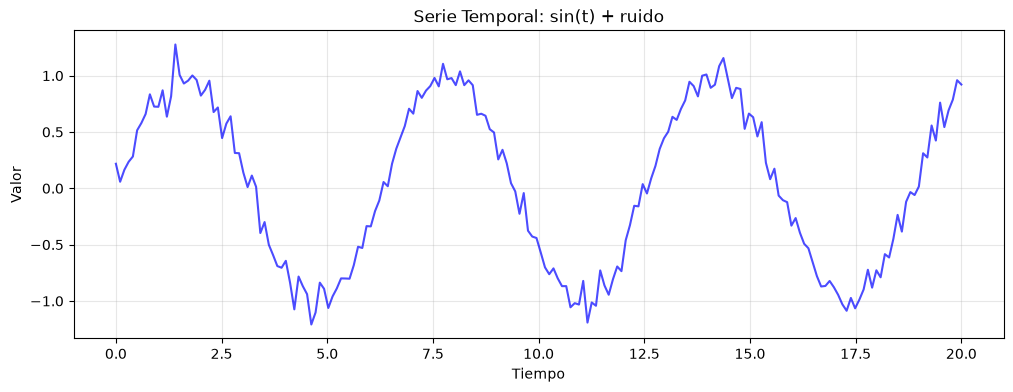


📊 Dataset preparado:
  X shape: (190, 10) (muestras, secuencia)
  y shape: (190,)
  Muestras de entrenamiento: 190

✅ Convertido a PyTorch tensors
  X_train: torch.Size([190, 10, 1])
  y_train: torch.Size([190, 1])


In [4]:
# 🔹 CELDA 4: Dataset (Serie Temporal)

print("\n" + "=" * 60)
print("DATASET: GENERAR SERIE TEMPORAL")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Genera datos de serie temporal (precios, temperatura, etc).
Preparamos datos para que LSTM pueda aprender patrones.

IDEA:
- Tenemos serie: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
- Creamos pares (entrada, salida):
  - Input: [1, 2, 3] → Output: 4
  - Input: [2, 3, 4] → Output: 5
  - Input: [3, 4, 5] → Output: 6
  ...

Así LSTM aprende: "Si ves [x, x+1, x+2], predice x+3"
""")

# Generar serie temporal sintética (onda sinusoidal + ruido)
t = np.linspace(0, 20, 200)  # 200 timepoints
data = np.sin(t) + np.random.normal(0, 0.1, len(t))  # sin(t) + ruido

print(f"\nSerie temporal generada:")
print(f"  Puntos: {len(data)}")
print(f"  Patrón: sin(t) + ruido")
print(f"  Rango: [{data.min():.2f}, {data.max():.2f}]")

# Visualizar
plt.figure(figsize=(12, 4))
plt.plot(t, data, 'b-', alpha=0.7, linewidth=1.5)
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Serie Temporal: sin(t) + ruido')
plt.grid(True, alpha=0.3)
plt.show()

# Preparar datos para LSTM
sequence_length = 10  # LSTM ve 10 pasos para predecir el siguiente

X = []  # Inputs (secuencias)
y = []  # Outputs (siguiente valor)

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])  # 10 pasos
    y.append(data[i+sequence_length])    # Siguiente paso

X = np.array(X)
y = np.array(y)

print(f"\n📊 Dataset preparado:")
print(f"  X shape: {X.shape} (muestras, secuencia)")
print(f"  y shape: {y.shape}")
print(f"  Muestras de entrenamiento: {len(X)}")

# Convertir a PyTorch
X_train = torch.FloatTensor(X).unsqueeze(-1)  # (batch, seq_len, 1)
y_train = torch.FloatTensor(y).unsqueeze(-1)  # (batch, 1)

print(f"\n✅ Convertido a PyTorch tensors")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")



TRAINING LSTM

¿QUÉ HACE ESTA CELDA?
Entrena LSTM en la serie temporal.

PROCESO:
1. Forward: LSTM procesa 10 pasos → predice paso 11
2. Calcula error (MSE)
3. Backward: Calcula gradientes
4. Optimizer: Actualiza pesos
5. Repetir 100 epochs


Entrenando LSTM por 100 epochs...

Epoch 20/100: Loss=0.040030
Epoch 40/100: Loss=0.015821
Epoch 60/100: Loss=0.014019
Epoch 80/100: Loss=0.012959
Epoch 100/100: Loss=0.017880

✅ Training complete!
Loss inicial: 0.522047
Loss final: 0.017880
Mejora: 96.6%


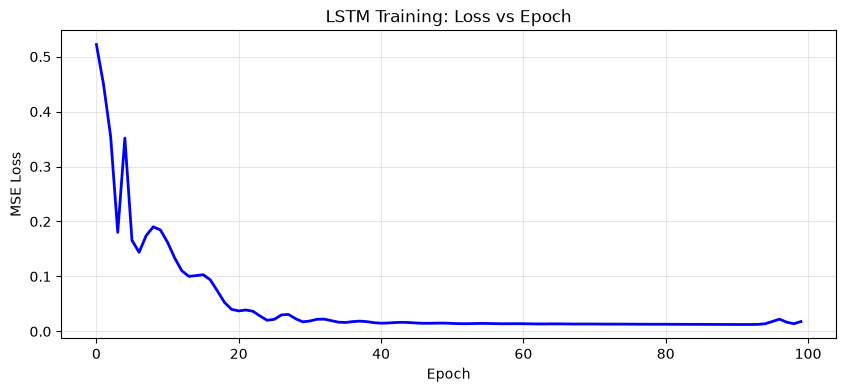

In [5]:
# 🔹 CELDA 5: Training Loop

print("\n" + "=" * 60)
print("TRAINING LSTM")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Entrena LSTM en la serie temporal.

PROCESO:
1. Forward: LSTM procesa 10 pasos → predice paso 11
2. Calcula error (MSE)
3. Backward: Calcula gradientes
4. Optimizer: Actualiza pesos
5. Repetir 100 epochs
""")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Crear modelo
model = LSTMModel(input_size=1, hidden_size=50, num_layers=2, output_size=1).to(device)

# Loss y optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
epochs = 100
losses = []

X_train_device = X_train.to(device)
y_train_device = y_train.to(device)

print(f"\nEntrenando LSTM por {epochs} epochs...\n")

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_device)
    loss = criterion(outputs, y_train_device)
    losses.append(loss.item())
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}: Loss={loss.item():.6f}")

print(f"\n✅ Training complete!")
print(f"Loss inicial: {losses[0]:.6f}")
print(f"Loss final: {losses[-1]:.6f}")
print(f"Mejora: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")

# Graficar loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training: Loss vs Epoch')
plt.grid(True, alpha=0.3)
plt.show()



PREDICCIONES: LSTM vs REAL

¿QUÉ HACE ESTA CELDA?
Usa LSTM entrenado para predecir valores futuros.

PROCESO:
1. Toma últimos 10 valores reales
2. LSTM predice el siguiente
3. Agrega predicción a secuencia
4. Repite para predecir 30 pasos adelante


✅ Predicción completa: 30 pasos futuros


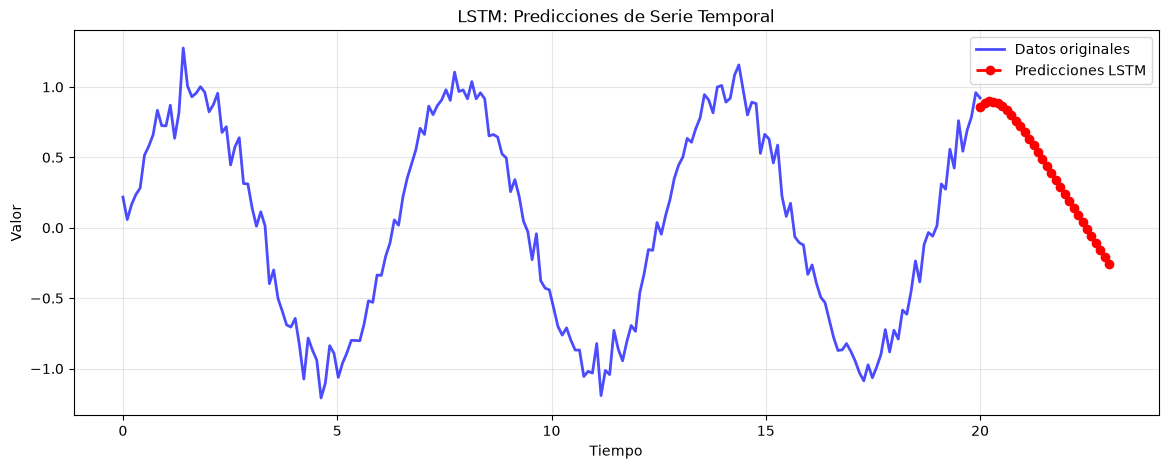


📊 Métricas:
  MSE en entrenamiento: 0.012968
  Predicción futura: ✅ Completada


In [7]:
# 🔹 CELDA 6: Predicciones

print("\n" + "=" * 60)
print("PREDICCIONES: LSTM vs REAL")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Usa LSTM entrenado para predecir valores futuros.

PROCESO:
1. Toma últimos 10 valores reales
2. LSTM predice el siguiente
3. Agrega predicción a secuencia
4. Repite para predecir 30 pasos adelante
""")

model.eval()

# Predicción paso a paso
with torch.no_grad():
    # Comenzar con últimos 10 valores
    current_seq = X_train[-1:].to(device)  # (1, 10, 1)
    
    predictions = []
    for _ in range(30):  # Predecir 30 pasos
        # LSTM predice siguiente
        next_val = model(current_seq)
        predictions.append(next_val.cpu().numpy()[0, 0])
        
        # Actualizar secuencia: quitar primero, agregar predicción
        current_seq = torch.cat([
            current_seq[:, 1:, :],                    # (1, 9, 1)
            next_val.reshape(1, 1, 1)                 # (1, 1, 1)
        ], dim=1)

predictions = np.array(predictions)

print(f"\n✅ Predicción completa: {len(predictions)} pasos futuros")

# Visualizar: histórico + predicciones
plt.figure(figsize=(14, 5))

# Histórico
plt.plot(t, data, 'b-', linewidth=2, label='Datos originales', alpha=0.7)

# Predicciones
t_future = np.linspace(t[-1], t[-1] + (t[1] - t[0]) * 30, 30)
plt.plot(t_future, predictions, 'r--', linewidth=2, label='Predicciones LSTM', marker='o')

plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('LSTM: Predicciones de Serie Temporal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calcular error en entrenamiento
with torch.no_grad():
    y_pred_train = model(X_train_device)
    mse_train = criterion(y_pred_train, y_train_device).item()

print(f"\n📊 Métricas:")
print(f"  MSE en entrenamiento: {mse_train:.6f}")
print(f"  Predicción futura: ✅ Completada")
